# `collabgraph` tutorial

This notebook walks end-to-end through the `collabgraph` package:

1. Read `data/collaborators.xlsx` and inspect the data.
2. Connect to Neo4j and create schema constraints.
3. Ingest the rows with idempotent `MERGE` writes.
4. Verify the graph with parameterized Cypher queries.
5. Build a NetworkX graph and render customized static visualizations.
6. Get ready-to-paste Cypher for Neo4j Browser / Bloom.

**Prerequisites**
- A local Neo4j instance reachable at the URI in `.env` (default `bolt://localhost:7687`).
- `uv sync` has been run from the project root (so the `collabgraph` package is importable).

## 1. Setup

Make the project root the current working directory so that the relative path `data/collaborators.xlsx` and the project-local `.env` are picked up automatically.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

# Run everything from the project root, regardless of where the kernel started.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

DATA_PATH = PROJECT_ROOT / "data" / "collaborators.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Excel path:  ", DATA_PATH)
print("Outputs dir: ", OUTPUT_DIR)


Project root: /Users/d3y010/repos/crvernon/collaborators
Excel path:   /Users/d3y010/repos/crvernon/collaborators/data/collaborators.xlsx
Outputs dir:  /Users/d3y010/repos/crvernon/collaborators/notebooks/_outputs


## 2. Read and inspect the input file

`read_collaborators` validates required columns, strips whitespace from string fields, coerces `latitude` / `longitude` to numeric, and drops rows missing required values.

In [2]:
from collabgraph import read_collaborators

df = read_collaborators(DATA_PATH)
print(f"rows = {len(df)}, cols = {list(df.columns)}")
df.head()


rows = 6, cols = ['collaborator', 'sector', 'affiliation', 'address', 'latitude', 'longitude', 'crs']


,collaborator,sector,affiliation,address,latitude,longitude,crs
0,Brett Pflugrath,Hydropower,Pacific Northwest National Laboratory,"Pacific Northwest National Laboratory, Richlan...",46.348154,-119.280255,EPSG:3857
1,Alison Colotelo,Hydropower,Pacific Northwest National Laboratory,"Pacific Northwest National Laboratory, Richlan...",46.348154,-119.280255,EPSG:3857
2,Sterling Watson,Engineering,Natel Energy,"Natel Energy, Alameda, CA 94501, USA",37.785678,-122.311587,EPSG:3857
3,Jonas Haug,Hydraulic Engineering,University of Innsbruck,"University of Innsbruck, 6020 Innsbruck, Austria",47.263922,11.343095,EPSG:3857
4,Abe Schneider,CTO,Natel Energy,"Natel Energy, Alameda, CA 94501, USA",37.785678,-122.311587,EPSG:3857


In [3]:
summary = {
    "unique_collaborators": df["collaborator"].nunique(),
    "unique_sectors": df["sector"].nunique(),
    "unique_affiliations": df["affiliation"].nunique(),
}
summary

{'unique_collaborators': 6, 'unique_sectors': 4, 'unique_affiliations': 3}

## 3. Connect to Neo4j and ensure schema

Connection settings are loaded from `NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD`, and `NEO4J_DATABASE` (with values from a project-local `.env` file applied automatically).

`init_schema()` creates uniqueness constraints on `Collaborator.name`, `Sector.name`, and `Affiliation.name`, plus a composite index on `Affiliation.(latitude, longitude)`. It is safe to run repeatedly.

In [4]:
from collabgraph import Neo4jIngestor, load_settings

settings = load_settings()
print(f"uri={settings.uri}  user={settings.user}  database={settings.database}")

with Neo4jIngestor(
    settings.uri, settings.user, settings.password, settings.database
) as ing:
    ing.verify_connectivity()
    ing.init_schema()

print("Connected and schema ensured.")

uri=bolt://localhost:7687  user=neo4j  database=neo4j
Connected and schema ensured.


## 4. Ingest the data

All writes use `MERGE`, so re-running this cell creates-or-updates nodes/relationships rather than duplicating them.

The graph schema produced is:

```
(:Collaborator {name})-[:AFFILIATED_WITH]->(:Affiliation {name, address, latitude, longitude, crs})
(:Collaborator)-[:WORKS_IN]->(:Sector {name})
(:Sector)-[:PRESENT_AT]->(:Affiliation)
```

In [5]:
with Neo4jIngestor(
    settings.uri, settings.user, settings.password, settings.database
) as ing:
    n_written = ing.ingest(df)

print(f"Wrote {n_written} row(s) to Neo4j.")

Wrote 6 row(s) to Neo4j.


### Idempotency check

Running `ingest` again should leave the node and relationship counts unchanged.

In [6]:
from neo4j import GraphDatabase


def graph_counts() -> dict[str, int]:
    drv = GraphDatabase.driver(settings.uri, auth=(settings.user, settings.password))
    try:
        with drv.session(database=settings.database) as session:
            row = session.run(
                """
                MATCH (c:Collaborator) WITH count(c) AS collaborators
                MATCH (s:Sector)       WITH collaborators, count(s) AS sectors
                MATCH (a:Affiliation)  WITH collaborators, sectors, count(a) AS affiliations
                MATCH ()-[r]->()       RETURN collaborators, sectors, affiliations, count(r) AS relationships
                """
            ).single()
    finally:
        drv.close()
    return dict(row)


before = graph_counts()
with Neo4jIngestor(
    settings.uri, settings.user, settings.password, settings.database
) as ing:
    ing.ingest(df)
after = graph_counts()

print("before:", before)
print("after :", after)
assert before == after, "MERGE-based ingest should be idempotent"
print("Idempotency confirmed.")

before: {'collaborators': 6, 'sectors': 4, 'affiliations': 3, 'relationships': 16}
after : {'collaborators': 6, 'sectors': 4, 'affiliations': 3, 'relationships': 16}
Idempotency confirmed.


## 5. Query the graph with the bundled Cypher snippets

`cypher_examples` ships nine named, parameter-friendly snippets you can list, fetch, and run directly.

In [7]:
from collabgraph.cypher_examples import (
    BLOOM_PERSPECTIVE_HINT,
    get_example,
    list_examples,
)

list_examples()

['affiliation_geo',
 'affiliations_in_sector',
 'co_affiliated_collaborators',
 'collaborators_at_affiliation',
 'collaborators_by_sector',
 'counts',
 'everything',
 'sectors_at_affiliation',
 'shortest_path_between_collaborators']

In [8]:
import pandas as pd


def run_cypher(name: str, **params) -> pd.DataFrame:
    """Run a named Cypher snippet and return the result as a DataFrame."""
    cypher = get_example(name)
    drv = GraphDatabase.driver(settings.uri, auth=(settings.user, settings.password))
    try:
        with drv.session(database=settings.database) as session:
            return session.run(cypher, **params).to_df()
    finally:
        drv.close()


run_cypher("counts")

,collaborators,sectors,affiliations
0,6,4,3


In [9]:
run_cypher("affiliation_geo")

,affiliation,address,latitude,longitude,crs
0,Natel Energy,"Natel Energy, Alameda, CA 94501, USA",37.785678,-122.311587,EPSG:3857
1,Pacific Northwest National Laboratory,"Pacific Northwest National Laboratory, Richlan...",46.348154,-119.280255,EPSG:3857
2,University of Innsbruck,"University of Innsbruck, 6020 Innsbruck, Austria",47.263922,11.343095,EPSG:3857


In [10]:
sector = df["sector"].mode().iat[0]
print(f"Collaborators in sector '{sector}':")
run_cypher("collaborators_by_sector", sector=sector)

Collaborators in sector 'Hydropower':


,collaborator
0,Alison Colotelo
1,Brett Pflugrath
2,Ryan Harnish


In [11]:
affiliation = df["affiliation"].mode().iat[0]
print(f"Sectors present at affiliation '{affiliation}':")
run_cypher("sectors_at_affiliation", affiliation=affiliation)

Sectors present at affiliation 'Pacific Northwest National Laboratory':


,sector
0,Hydropower


In [12]:
run_cypher("co_affiliated_collaborators")

,affiliation,collaborator_a,collaborator_b
0,Natel Energy,Abe Schneider,Sterling Watson
1,Pacific Northwest National Laboratory,Alison Colotelo,Brett Pflugrath
2,Pacific Northwest National Laboratory,Alison Colotelo,Ryan Harnish
3,Pacific Northwest National Laboratory,Brett Pflugrath,Ryan Harnish


## 6. Build a NetworkX graph and render static visualizations

`build_networkx_graph` turns the same DataFrame into a `MultiDiGraph` whose nodes carry a `kind` attribute (`Collaborator`, `Sector`, `Affiliation`) used by `draw_graph` for styling.

In [13]:
%matplotlib inline

from collabgraph import build_networkx_graph, draw_graph

g = build_networkx_graph(df)
print(f"nodes = {g.number_of_nodes()}, edges = {g.number_of_edges()}")
kinds = {data["kind"] for _, data in g.nodes(data=True)}
rels = {d["rel"] for _, _, d in g.edges(data=True)}
print(f"node kinds         : {sorted(kinds)}")
print(f"relationship types : {sorted(rels)}")

nodes = 13, edges = 16
node kinds         : ['Affiliation', 'Collaborator', 'Sector']
relationship types : ['AFFILIATED_WITH', 'PRESENT_AT', 'WORKS_IN']


### 6a. Default rendering

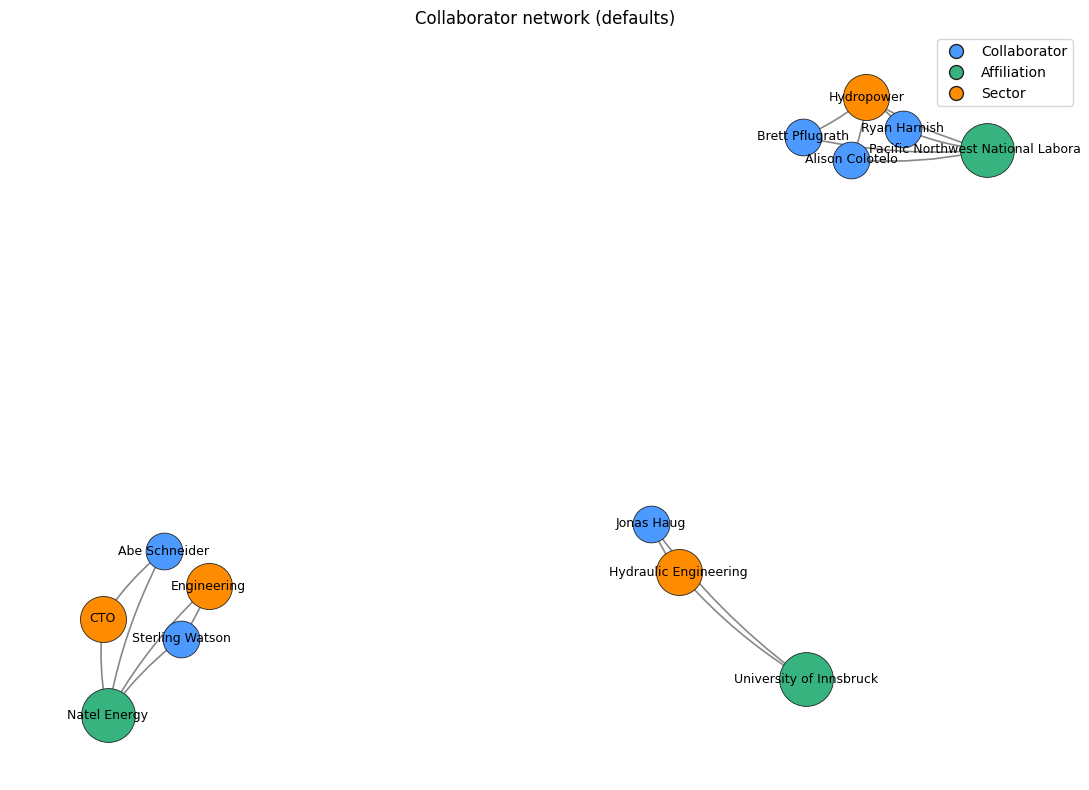

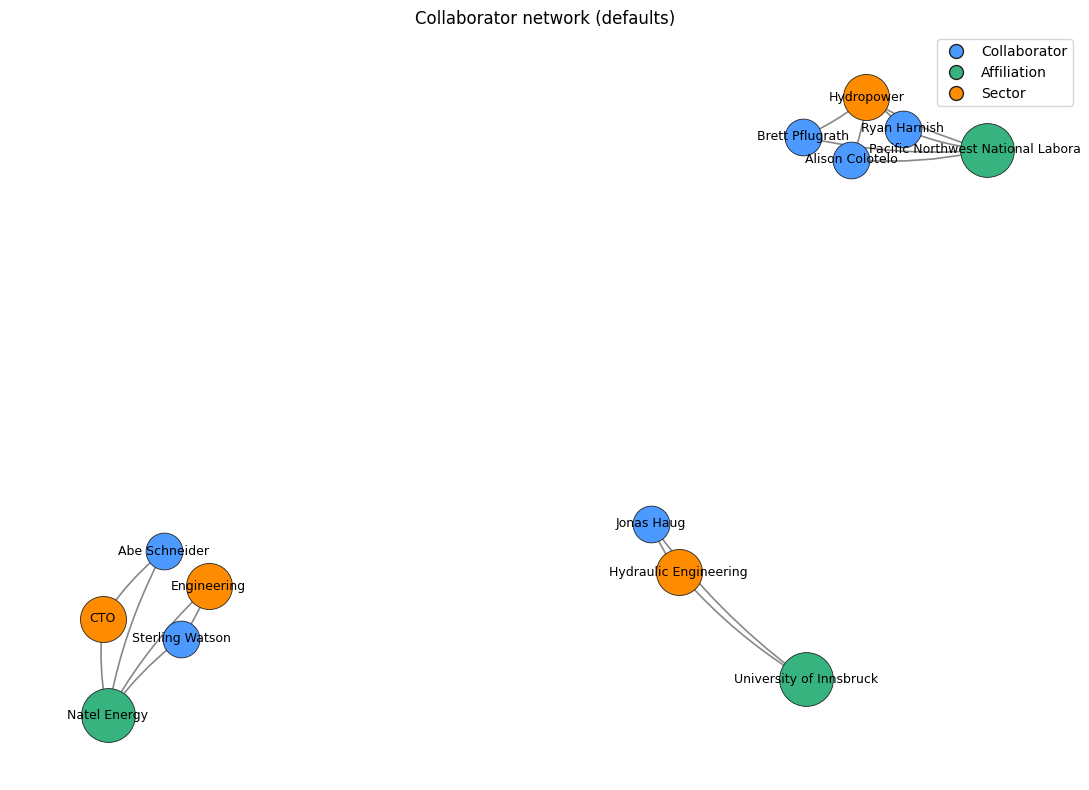

In [14]:
fig = draw_graph(
    g,
    layout="spring",
    seed=7,
    figsize=(11, 8),
    title="Collaborator network (defaults)",
    output=OUTPUT_DIR / "01_default.png",
)
fig

### 6b. Customized colors, sizes, and edge labels

All styling is overridable. Below we use a different palette, larger affiliation nodes, the `kamada_kawai` layout, and turn on relationship-type labels.

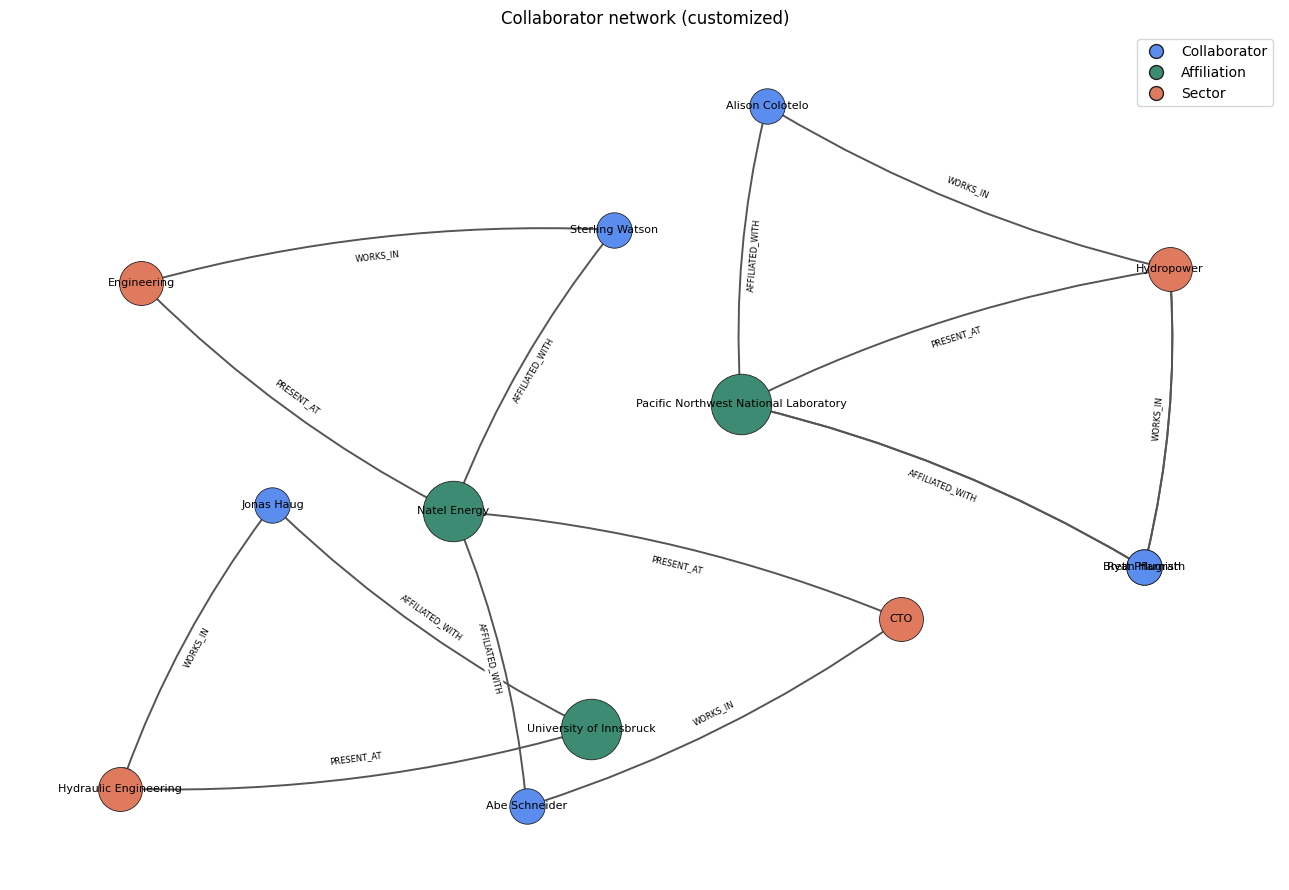

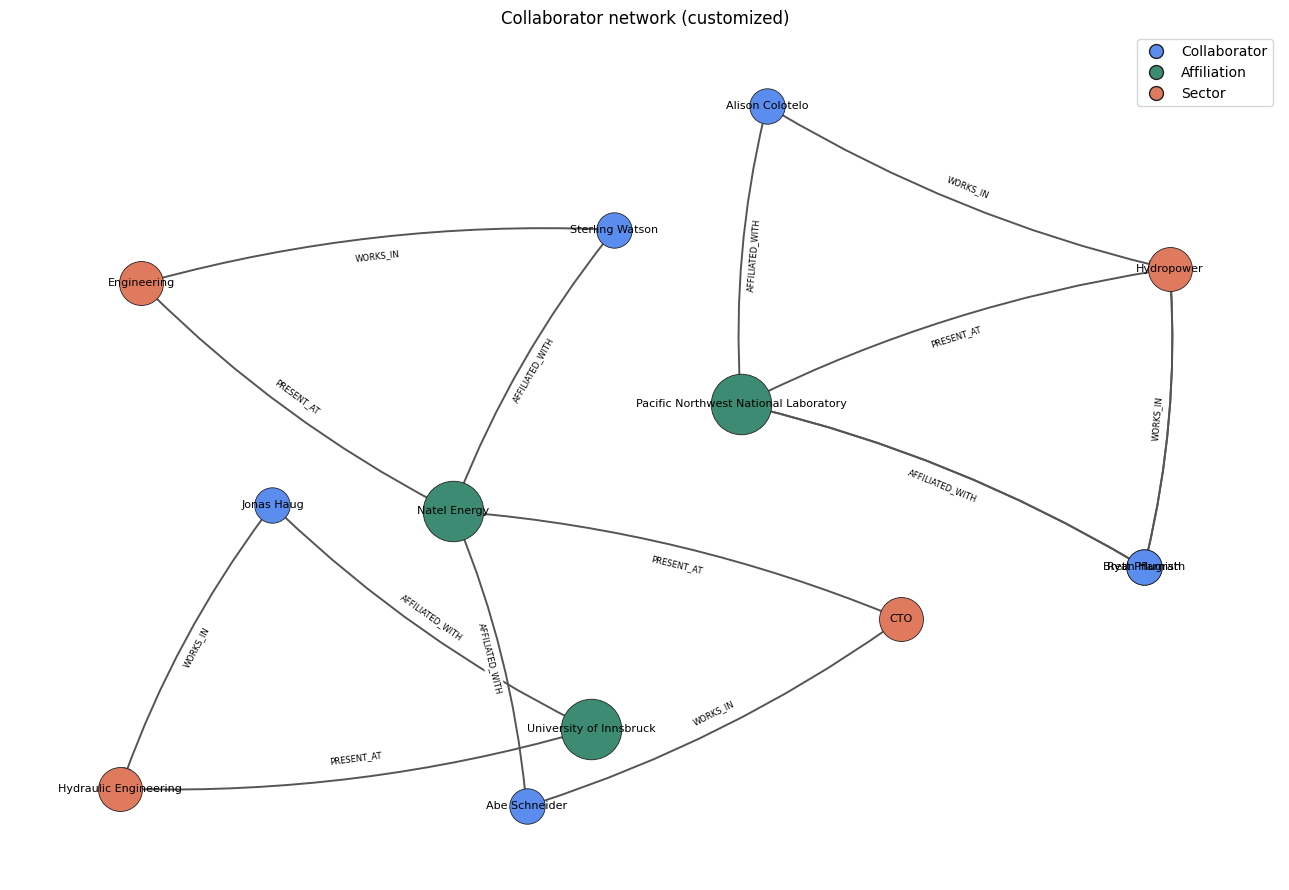

In [15]:
fig = draw_graph(
    g,
    layout="kamada_kawai",
    node_colors={
        "Collaborator": "#5B8DEF",
        "Sector": "#E07A5F",
        "Affiliation": "#3D8B72",
    },
    node_sizes={
        "Collaborator": 650,
        "Sector": 1000,
        "Affiliation": 1900,
    },
    edge_color="#555555",
    edge_width=1.4,
    label_font_size=8,
    edge_labels=True,
    edge_label_font_size=6,
    figsize=(13, 9),
    title="Collaborator network (customized)",
    output=OUTPUT_DIR / "02_custom.png",
)
fig

### 6c. Filtered sub-graph

Use `filter_sector` / `filter_affiliation` to restrict the rendered graph to collaborators (and their immediate neighbors) in given sector(s) and/or affiliation(s).

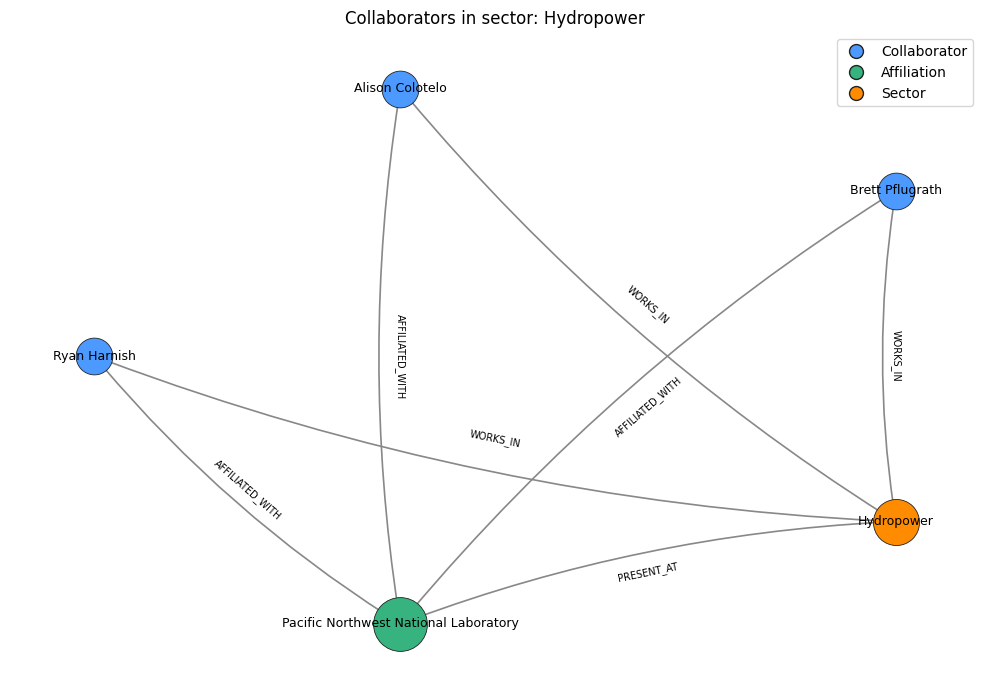

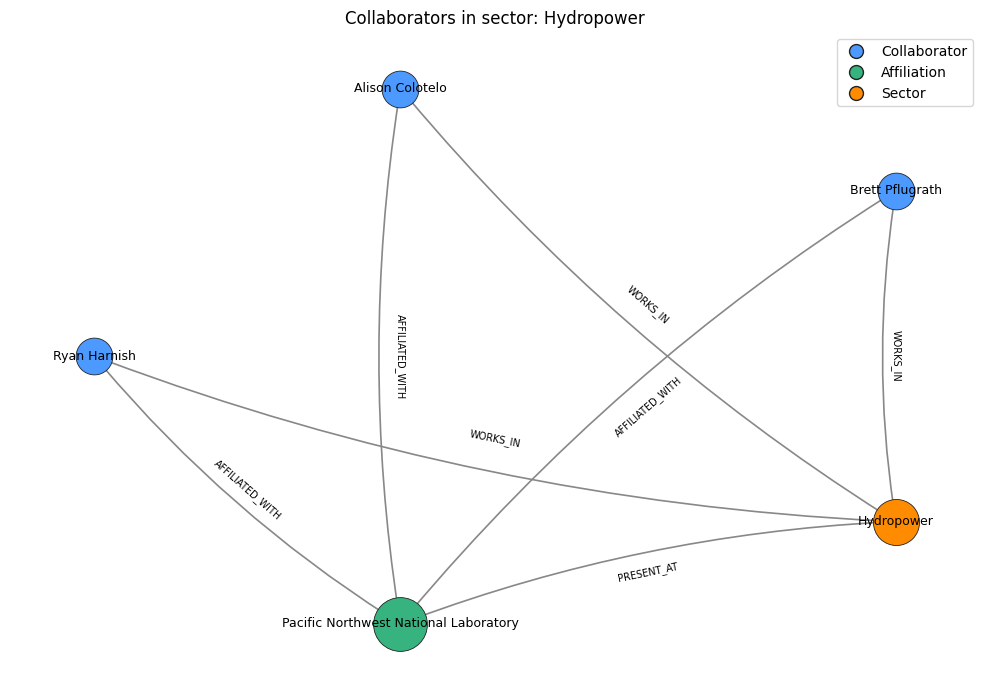

In [16]:
focus_sector = df["sector"].mode().iat[0]
fig = draw_graph(
    g,
    layout="shell",
    figsize=(10, 7),
    title=f"Collaborators in sector: {focus_sector}",
    filter_sector=focus_sector,
    edge_labels=True,
    output=OUTPUT_DIR / f"03_filter_{focus_sector.replace(' ', '_')}.png",
)
fig

## 7. Visualize in Neo4j Browser / Bloom

Paste the snippet below into Neo4j Browser to see everything at once:

In [17]:
print(get_example("everything"))

MATCH (n)
OPTIONAL MATCH (n)-[r]->(m)
RETURN n, r, m


In [18]:
print(BLOOM_PERSPECTIVE_HINT)

Suggested Bloom perspective:

Categories:
  - Collaborator  (caption: name, color: #4C9AFF)
  - Sector        (caption: name, color: #FF8B00)
  - Affiliation   (caption: name, color: #36B37E,
                   tooltip: address, latitude, longitude)

Relationships:
  - AFFILIATED_WITH : Collaborator -> Affiliation
  - WORKS_IN        : Collaborator -> Sector
  - PRESENT_AT      : Sector       -> Affiliation

Useful search phrases:
  - "Collaborator AFFILIATED_WITH Affiliation"
  - "Sector PRESENT_AT Affiliation"
  - "Collaborator WORKS_IN Sector PRESENT_AT Affiliation"



## 8. (Optional) Wipe the graph

Uncomment the cell below to remove every node and relationship in the database. Use with care.

In [19]:
# with Neo4jIngestor(
#     settings.uri, settings.user, settings.password, settings.database
# ) as ing:
#     ing.clear()
# print("Database cleared.")

## What's next

- Re-run `read_collaborators` + `Neo4jIngestor.ingest` whenever the Excel file changes; thanks to `MERGE` it just updates in place.
- Use the Typer CLI for the same workflow on the command line:

  ```bash
  uv run collabgraph init-schema
  uv run collabgraph ingest --path data/collaborators.xlsx
  uv run collabgraph viz --layout kamada_kawai --edge-labels --output graph.png
  uv run collabgraph cypher --name collaborators_by_sector
  ```